<a href="https://colab.research.google.com/github/keiseki-eng/E_SHIKAKU/blob/main/%E6%8F%90%E5%87%BA%E7%94%A8_Cifar10_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 修了課題DEMO④　CIFAR10



[JDLAが策定しているバージョン](https://www.jdla.org/certificate/engineer/)に合わせるために、以下のセルの実行をお願いします．

（#コメントアウト されているものは必要ありません）

また実行完了後に「ランタイムの再起動」をして下さい．

（以下のセルの実行は、最初にしていただければ、以降必要ありません．）

In [57]:
%%capture
# !pip uninstall matplotlib -y
# !pip install matplotlib==3.7.1

# !pip uninstall opencv-python -y
# !pip install opencv-python==4.7.0.72

!pip install torch==2.3.0 torchvision==0.18.0 torchaudio==2.3.0 --index-url https://download.pytorch.org/whl/cu118

##はじめに
この修了課題では、Pytorchを使って「CIFAR10」という画像データセットの分類を行っていきます。  
今回使用するネットワーク構成は
    
    conv2d - relu - MaxPool2d -
    conv2d - relu - MaxPool2d -
    flatten -
    Linear - relu -
    Linear - relu - Linear
上記のようなCNNとなっています。  
ここで、viewとはサイズを１度調整するコマンドのことで、各要素の値そのものに変化はありません。  
また、Linearは線形結合を表しています。


##作成までの流れ
大まかな流れとして
1. データのダウンロードと正規化  
   torchvisionというライブラリを使用して、CIFAR10の訓練用のデータ、テスト用のデータをダウンロードします。  
   また、ダウンロードした画像に対して正規化を行います。

2. モデルの構築  
   学習を行うモデルの各層の役割を理解して、構築します。

3. 損失関数などの設定  
   学習を行うのに必要な損失関数などの設定を行います。

4. 学習と結果  
   訓練データで学習を行い、どのくらいの精度があるのかを、テスト用データを使って確認します。

##必要なライブラリーのインポートとGoogleDriveへの接続

In [58]:
#GoogleDriveへの接続を行う
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [59]:
#必要なライブラリーのインポート
import numpy as np
import matplotlib.pyplot as plt
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

#ダウンロードに必要なライブラリーのインポート
import pickle
from PIL import Image
import os

#1.データのダウンロードと正規化

## データのダウンロード

今回使用するデータを「wget」コマンドでダウンロードします。  
ダウンロードしたデータを直列に配置し、画像に変換する処理を行っていますが、  
今回はモデルの作成と学習が目的ですので、気にせず実行してください。

In [60]:
!wget 'https://drive.google.com/uc?export=download&id=15kspx4XmoR5Kh1fKkdxjjPcn_Y8tkaP3' -O train.pickle

--2026-06-18 07:48:50--  https://drive.google.com/uc?export=download&id=15kspx4XmoR5Kh1fKkdxjjPcn_Y8tkaP3
Resolving drive.google.com (drive.google.com)... 142.250.101.101, 142.250.101.100, 142.250.101.113, ...
Connecting to drive.google.com (drive.google.com)|142.250.101.101|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=15kspx4XmoR5Kh1fKkdxjjPcn_Y8tkaP3&export=download [following]
--2026-06-18 07:48:50--  https://drive.usercontent.google.com/download?id=15kspx4XmoR5Kh1fKkdxjjPcn_Y8tkaP3&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 142.250.101.132, 2607:f8b0:4023:c06::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|142.250.101.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 31319904 (30M) [application/octet-stream]
Saving to: ‘train.pickle’

train.pickle        100%[===================>]  29.87M  72.5

In [61]:
!wget 'https://drive.google.com/uc?export=download&id=1-QKklgEpROkVIUnaLQ9dKgfCK_mp78xN' -O val.pickle

--2026-06-18 07:48:53--  https://drive.google.com/uc?export=download&id=1-QKklgEpROkVIUnaLQ9dKgfCK_mp78xN
Resolving drive.google.com (drive.google.com)... 142.250.101.101, 142.250.101.100, 142.250.101.113, ...
Connecting to drive.google.com (drive.google.com)|142.250.101.101|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1-QKklgEpROkVIUnaLQ9dKgfCK_mp78xN&export=download [following]
--2026-06-18 07:48:53--  https://drive.usercontent.google.com/download?id=1-QKklgEpROkVIUnaLQ9dKgfCK_mp78xN&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 142.250.101.132, 2607:f8b0:4023:c06::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|142.250.101.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6264552 (6.0M) [application/octet-stream]
Saving to: ‘val.pickle’

val.pickle          100%[===================>]   5.97M  34.6MB

下のセルで画像ファイルとして保存する処理を行っています。  
実行に平均1分程度かかりますが、データのダウンロードが完了します。

In [62]:
# バイナリファイルを読み込んでから、画像データに変換処理を行う。
def parse_pickle(rawdata, dataset_name):
    for i in range(10):
        dir = dataset_name + "/" + f"{i:02d}"
        if not os.path.exists(dir):
            os.makedirs(dir)
    m = len(rawdata["data"])
    for i in range(m):
        filename = f'{i}.png'
        label = rawdata["label"][i]
        data = rawdata["data"][i]
        data = data.reshape(3, 32, 32)
        data = np.swapaxes(data, 0, 2)
        data = np.swapaxes(data, 0, 1)
        with Image.fromarray(data) as img:
            img.save(f"{dataset_name}/{label:02d}/{filename}")

train = {'label':[], 'data':[]}
with open('train.pickle', "rb") as fp:
  train = pickle.load(fp, encoding="latin-1")
parse_pickle(train, "train")

with open('val.pickle', "rb") as fp:
  val = pickle.load(fp, encoding="latin-1")
parse_pickle(val, "val")

##データ拡張とデータセット作成
画像認識において「データ拡張」は汎化性能を上げる重要な役割を果たします。  
torchvision.transforms という PyTorch のサブライブラリを用いてデータ拡張を行います。  
また、transforms.Composeの中に記入することで、記入したtransformのコマンドを一度に実行することができます。

今回は一般的に必要な  

*  画像のテンソル化 ( transforms.ToTensor() )  
*  RGBの平均と標準偏差をそれぞれ0.5に設定する正規化 ( transforms.Nomalize())

を行いました。

Pytorchが提供しているその他のtransformのURLを記載しておくので、精度が上がる手法をそれぞれ試してみてください。  
データ拡張:https://pytorch.org/vision/stable/transforms.html

In [63]:
# 追加のデータ拡張例
transform = transforms.Compose([
    transforms.RandomHorizontalFlip(), # 左右反転
    transforms.RandomCrop(32, padding=4), # ランダムクロップ
    transforms.AutoAugment(
        transforms.AutoAugmentPolicy.CIFAR10
    ),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

次にバッチサイズとデータをまとめる処理になります。

In [64]:
# バッチサイズの設定
batch_size = 64

# データローダーの設定
trainset = torchvision.datasets.ImageFolder(root='train', transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)

valset = torchvision.datasets.ImageFolder(root='val', transform=transform)
valloader = torch.utils.data.DataLoader(valset, batch_size=batch_size,shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

データの量を確認します。

In [65]:
print('学習データ:', len(trainset))
print('検証データ:', len(valset))

学習データ: 10000
検証データ: 2000


##データの確認
ここで一度、データがどのようなものなのか確認してみましょう。

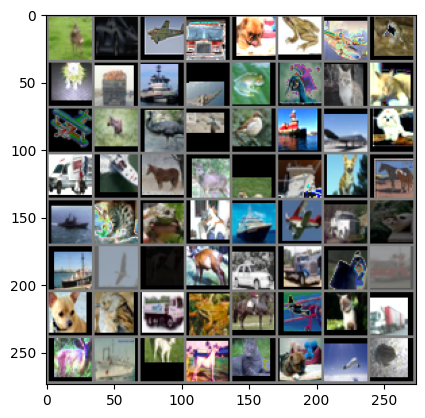

deer  car   plane truck dog   frog  plane frog  dog   truck ship  plane frog  bird  cat   cat   plane deer  bird  deer  bird  ship  plane dog   truck ship  horse deer  dog   ship  dog   horse ship  cat   frog  dog   ship  plane truck cat   ship  bird  horse deer  car   truck dog   truck dog   bird  truck frog  horse plane cat   truck deer  ship  dog   horse cat   dog   plane frog 


In [66]:
# 画像を格子状に表示する関数
def imshow(img):
    img = img / 2 + 0.5     #非正規化する
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


#画像をいくつか取得
dataiter = iter(trainloader)
images, labels = next(dataiter)

#画像を表示する
imshow(torchvision.utils.make_grid(images))
#画像の下にそれぞれのラベルを表示
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))

# 2.モデルの構築
先ほど紹介したCNNを作成してみましょう。

今回のネットワーク構成：

    conv2d - relu - MaxPool2d -
    conv2d - relu - MaxPool2d -
    flatten -
    Linear - relu -
    Linear - relu - Linear

In [67]:
# シンプルなCNNモデルの構築
class Net(nn.Module):
    def __init__(self):
      #まずここで各層がどのようなものか定義をしておく
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
      #initで定義されたものを実際に配置する
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

net = Net()

#3.損失関数などの設定
損失関数(criterion)と最適化手法(optimizer)について設定します。  
Pytorchが提供しているcriterionとoptimizerのURLを記載しておくので、精度が上がる手法をそれぞれ試してみてください。  


*   criterion:https://pytorch.org/docs/stable/nn.html#loss-functions
*   optimizer:https://pytorch.org/docs/stable/optim.html


#4.学習と結果

学習を実際に行ってみましょう。  
様子を確認するためにLossの平均を2000ミニバッチごとに表示してみます。

##結果のモデルを保存する


In [68]:
# cnn_weight_path = './cnn_weight.pth'
# torch.save(net.state_dict(), cnn_weight_path)

##結果を検証用データで確認する

# 5.発展的なモデルを用いて学習する

今回は発展的なモデルとして「VGG11」を試してみます。

また、ほかのモデルのコードなどを参照したい場合は  
https://github.com/kuangliu/pytorch-cifar  
を見てみましょう。

その他にResNet などもありますので、試してみて下さい。  
ResNetがどういうものなのかは以下のURLで詳しく述べているので、是非読んでみてください。

代表的モデル「ResNet」、「DenseNet」を詳細解説！：https://deepsquare.jp/2020/04/resnet-densenet/



##結果のモデルを保存する

先程作成したシンプルなCNNモデルよりも精度が悪化しますが、  
これはモデルの容量が大きくなったため学習量が足りていないことが原因です。  
転移学習を利用して、より学習させたモデルを利用することでVGGモデルの性能の本来の力を確認しましょう。

## 7. 高精度モデル (ResNet-18) を用いて学習する

ここでは、より高精度を狙えるResNet-18モデルを使用します。ResNetはディープラーニングにおいて非常に成功したアーキテクチャの一つで、"Residual Learning"という手法を用いて深いネットワークの学習を容易にしました。

VGGと同じく、`torchvision.models`から事前に学習済みのモデルをロードし、CIFAR-10の10クラスに合わせて最終層を変更します。

In [69]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
import torchvision

# # 事前学習済みResNet-18モデルのロード
# net_resnet = torchvision.models.resnet18(pretrained=True)

# # ResNetの最終層（全結合層）をCIFAR-10の10クラスに合わせて変更する。
# # ResNet-18の最後の全結合層は 'fc' と呼ばれる。
# num_ftrs = net_resnet.fc.in_features
# net_resnet.fc = nn.Linear(num_ftrs, 10)
net_resnet = torchvision.models.resnet18(pretrained=True)

# CIFAR向けに変更
net_resnet.conv1 = nn.Conv2d(
    3,
    64,
    kernel_size=3,
    stride=1,
    padding=1,
    bias=False
)

net_resnet.maxpool = nn.Identity()

num_ftrs = net_resnet.fc.in_features
net_resnet.fc = nn.Linear(num_ftrs, 10)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
net_resnet = net_resnet.to(device)

criterion = nn.CrossEntropyLoss(
    label_smoothing=0.1
)
optimizer = optim.SGD(
    net_resnet.parameters(),
    lr=0.003,
    momentum=0.9,
    weight_decay=5e-4
)

# Assuming epoch_num is defined as 50 based on the previous subtask
scheduler = CosineAnnealingLR(optimizer, T_max=50, eta_min=0)
print("Learning rate scheduler CosineAnnealingLR initialized.")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Learning rate scheduler CosineAnnealingLR initialized.


### ResNet-18モデルの学習

In [70]:
import torchvision
import torchvision.transforms as transforms
from torchvision.transforms import AutoAugment, AutoAugmentPolicy
import os
import pickle
from PIL import Image
import numpy as np
import torch # Explicitly import torch

# Ensure pickle files are downloaded before attempting to open them
!wget 'https://drive.google.com/uc?export=download&id=15kspx4XmoR5Kh1fKkdxjjPcn_Y8tkaP3' -O train.pickle
!wget 'https://drive.google.com/uc?export=download&id=1-QKklgEpROkVIUnaLQ9dKgfCK_mp78xN' -O val.pickle

# バイナリファイルを読み込んでから、画像データに変換処理を行う関数
def parse_pickle(rawdata, dataset_name):
    for i in range(10):
        dir = dataset_name + "/" + f"{i:02d}"
        if not os.path.exists(dir):
            os.makedirs(dir)
    m = len(rawdata["data"])
    for i in range(m):
        filename = f'{i}.png'
        label = rawdata["label"][i]
        data = rawdata["data"][i]
        data = data.reshape(3, 32, 32)
        data = np.swapaxes(data, 0, 2)
        data = np.swapaxes(data, 0, 1)
        with Image.fromarray(data) as img:
            img.save(f"{dataset_name}/{label:02d}/{filename}")

# train.pickle と val.pickle からデータセットを再作成
if not os.path.exists('train') or not os.path.exists('val'):
    print("Recreating 'train' and 'val' directories from pickle files...")
    train = {'label':[], 'data':[]}
    with open('train.pickle', "rb") as fp:
        train = pickle.load(fp, encoding="latin-1")
    parse_pickle(train, "train")

    val = {'label':[], 'data':[]}
    with open('val.pickle', "rb") as fp:
        val = pickle.load(fp, encoding="latin-1")
    parse_pickle(val, "val")
    print("'train' and 'val' directories recreated.")
else:
    print("'train' and 'val' directories already exist, skipping recreation.")

# Data loading and augmentation definitions
batch_size = 64

# Original transform for validation set
transform_val = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5,0.5,0.5),
        (0.5,0.5,0.5)
    )
])

# Enhanced transform for training set
transform_enhanced = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    AutoAugment(policy=AutoAugmentPolicy.CIFAR10),
    # transforms.RandAugment(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

trainset = torchvision.datasets.ImageFolder(root='train', transform=transform_enhanced)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)

valset = torchvision.datasets.ImageFolder(root='val', transform=transform_val)
valloader = torch.utils.data.DataLoader(valset, batch_size=batch_size,shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

epoch_num = 50

# Initialize lists to store metrics
train_losses_per_epoch = []
val_accuracies_per_epoch = []

# 学習ループの設定
print("Starting ResNet-18 Training...")
for epoch in range(epoch_num):
    net_resnet.train() # Set model to training mode
    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        inputs, labels = data
        optimizer.zero_grad()

        # テンソルをGPUに移動
        inputs = inputs.to(device)
        labels = labels.to(device)

        # forward + backward + optimize
        outputs = net_resnet(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        # Print loss every 2000 mini-batches
        if i % 2000 == 1999:
            print('[%d, %5d] loss: %.3f'
                  % (epoch + 1, i + 1, running_loss / 2000))
            running_loss = 0.0

    # Calculate and store average training loss for the epoch
    # Accumulate loss over the entire epoch for accurate epoch loss
    epoch_total_loss = 0.0
    net_resnet.eval() # Set model to evaluation mode for loss calculation on training set (optional, but good practice)
    with torch.no_grad():
        for inputs_val_loss, labels_val_loss in trainloader: # Use trainloader to calculate training loss
            inputs_val_loss, labels_val_loss = inputs_val_loss.to(device), labels_val_loss.to(device)
            outputs_val_loss = net_resnet(inputs_val_loss)
            loss_val_loss = criterion(outputs_val_loss, labels_val_loss)
            epoch_total_loss += loss_val_loss.item()
    avg_epoch_train_loss = epoch_total_loss / len(trainloader)
    train_losses_per_epoch.append(avg_epoch_train_loss)

    # Evaluate on validation set
    net_resnet.eval() # Set model to evaluation mode
    correct = 0
    total = 0
    with torch.no_grad():
        for data in valloader:
            images, labels = data
            images, labels = images.to(device), labels.to(device)
            outputs = net_resnet(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    current_val_accuracy = 100 * correct / total
    val_accuracies_per_epoch.append(current_val_accuracy)

    # スケジューラのステップを呼び出して学習率を更新
    scheduler.step()
    print(f"Epoch {epoch+1}: Learning rate updated to {optimizer.param_groups[0]['lr']:.6f}, "
          f"Training Loss: {avg_epoch_train_loss:.3f}, Validation Accuracy: {current_val_accuracy:.2f}%")

print('Finished Training ResNet-18')

# After training, save the final model weights
resnet_weight_path = './resnet_final_weight.pth'
torch.save(net_resnet.state_dict(), resnet_weight_path)
print(f"Final ResNet-18 model saved to {resnet_weight_path}")

--2026-06-18 07:49:04--  https://drive.google.com/uc?export=download&id=15kspx4XmoR5Kh1fKkdxjjPcn_Y8tkaP3
Resolving drive.google.com (drive.google.com)... 142.250.101.101, 142.250.101.100, 142.250.101.113, ...
Connecting to drive.google.com (drive.google.com)|142.250.101.101|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=15kspx4XmoR5Kh1fKkdxjjPcn_Y8tkaP3&export=download [following]
--2026-06-18 07:49:04--  https://drive.usercontent.google.com/download?id=15kspx4XmoR5Kh1fKkdxjjPcn_Y8tkaP3&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 142.250.101.132, 2607:f8b0:4023:c06::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|142.250.101.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 31319904 (30M) [application/octet-stream]
Saving to: ‘train.pickle’

train.pickle        100%[===================>]  29.87M  30.0

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/conv.py:456: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:919.)
  return F.conv2d(input, weight, bias, self.stride,


Epoch 1: Learning rate updated to 0.002997, Training Loss: 1.591, Validation Accuracy: 58.20%
Epoch 2: Learning rate updated to 0.002988, Training Loss: 1.302, Validation Accuracy: 71.80%
Epoch 3: Learning rate updated to 0.002973, Training Loss: 1.161, Validation Accuracy: 78.35%
Epoch 4: Learning rate updated to 0.002953, Training Loss: 1.103, Validation Accuracy: 80.45%
Epoch 5: Learning rate updated to 0.002927, Training Loss: 1.032, Validation Accuracy: 82.85%
Epoch 6: Learning rate updated to 0.002895, Training Loss: 0.986, Validation Accuracy: 84.80%
Epoch 7: Learning rate updated to 0.002857, Training Loss: 0.940, Validation Accuracy: 85.85%
Epoch 8: Learning rate updated to 0.002814, Training Loss: 0.913, Validation Accuracy: 87.10%
Epoch 9: Learning rate updated to 0.002766, Training Loss: 0.875, Validation Accuracy: 86.45%
Epoch 10: Learning rate updated to 0.002714, Training Loss: 0.846, Validation Accuracy: 87.50%
Epoch 11: Learning rate updated to 0.002656, Training Loss:

### 学習結果の可視化

訓練損失と検証正解率の推移をプロットして、モデルの学習状況を視覚的に確認します。

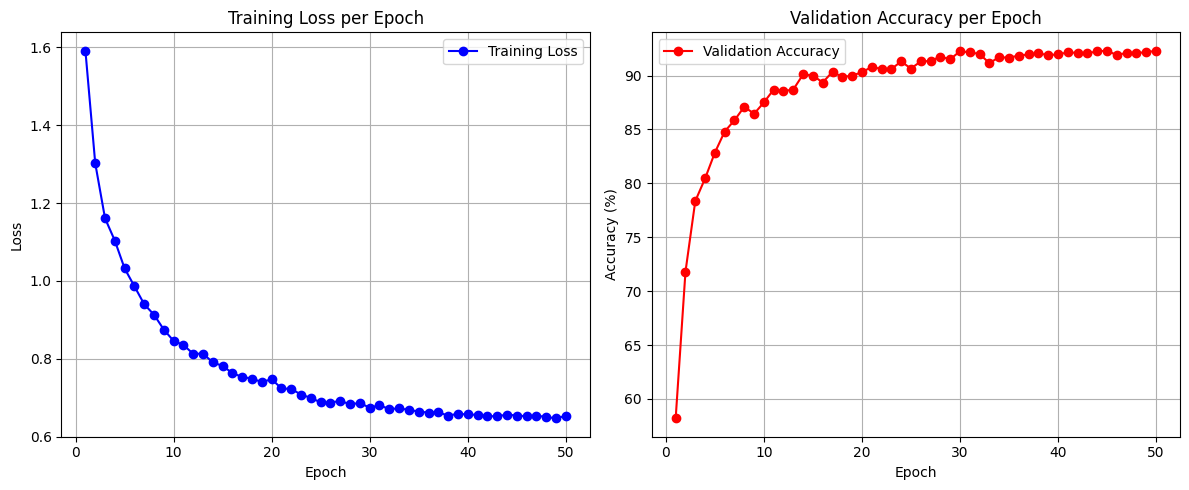

In [71]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses_per_epoch) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses_per_epoch, 'bo-', label='Training Loss')
plt.title('Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs, val_accuracies_per_epoch, 'ro-', label='Validation Accuracy')
plt.title('Validation Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


### 誤分類された画像の特定と可視化

モデルが誤って分類した画像を特定し、元の画像、正解ラベル、予測ラベルを合わせて表示することで、モデルの弱点を分析します。

Total misclassified images: 154


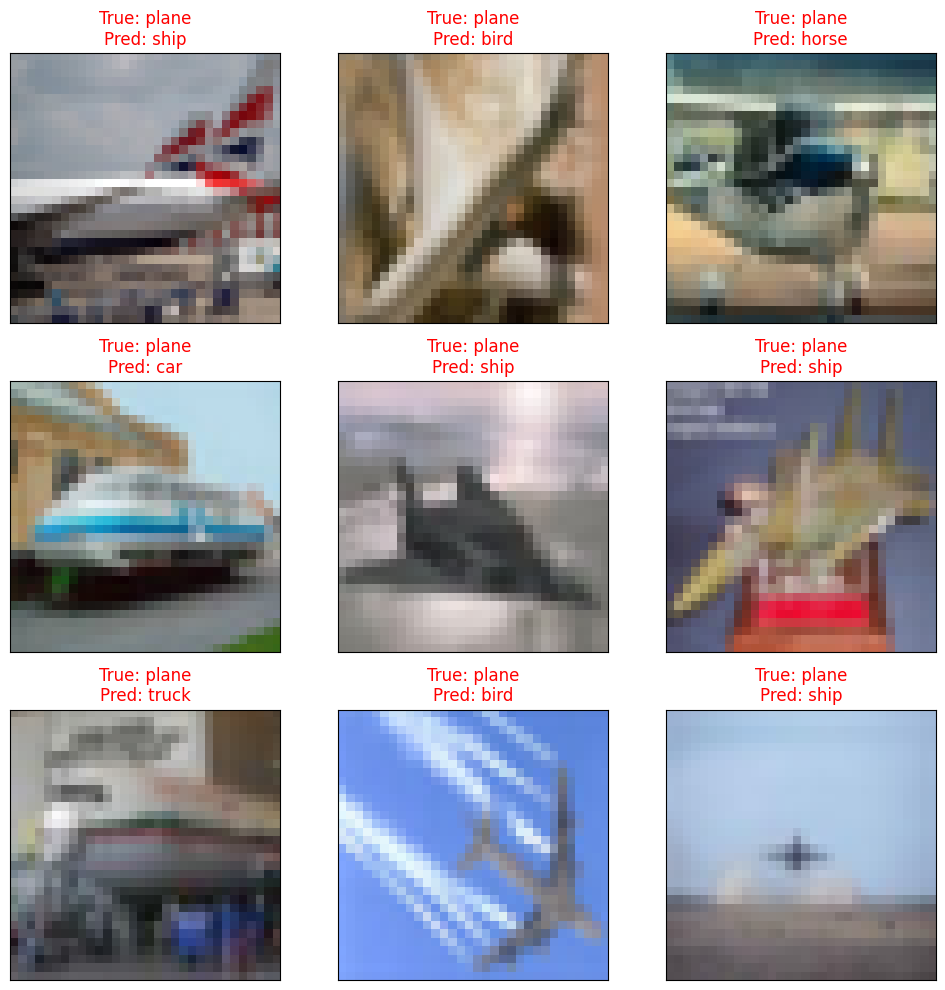

Saved 50 misclassified images to 'misclassified/' directory.


In [72]:
import matplotlib.pyplot as plt
import numpy as np

def imshow(img):
    img = img / 2 + 0.5     # 非正規化
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))


net_resnet.eval() # Set model to evaluation mode
misclassified_images = []
misclassified_labels = []
misclassified_preds = []

with torch.no_grad():
    for data in valloader:
        images, labels = data
        images, labels = images.to(device), labels.to(device)
        outputs = net_resnet(images)
        _, predicted = torch.max(outputs.data, 1)

        # 誤分類された画像を収集
        for i in range(len(labels)):
            if predicted[i] != labels[i]:
                misclassified_images.append(images[i].cpu())
                misclassified_labels.append(labels[i].cpu())
                misclassified_preds.append(predicted[i].cpu())

print(f"Total misclassified images: {len(misclassified_images)}")

# 誤分類された画像をいくつか表示
fig = plt.figure(figsize=(10, 10))
for i in range(min(9, len(misclassified_images))):
    ax = fig.add_subplot(3, 3, i + 1, xticks=[], yticks=[])
    imshow(misclassified_images[i])
    ax.set_title(f"True: {classes[misclassified_labels[i]]}\nPred: {classes[misclassified_preds[i]]}", color="red")
plt.tight_layout()
plt.show()

# Optionally, save misclassified images to a directory
if not os.path.exists('misclassified'):
    os.makedirs('misclassified')

for i in range(min(50, len(misclassified_images))): # Save up to 50 misclassified images
    img_tensor = misclassified_images[i]
    img_tensor = img_tensor / 2 + 0.5  # Denormalize for saving
    img_np = np.transpose(img_tensor.numpy(), (1, 2, 0))
    img_pil = Image.fromarray((img_np * 255).astype(np.uint8))
    true_label_name = classes[misclassified_labels[i]]
    pred_label_name = classes[misclassified_preds[i]]
    img_pil.save(f"misclassified/img_{i}_true_{true_label_name}_pred_{pred_label_name}.png")
print(f"Saved {min(50, len(misclassified_images))} misclassified images to 'misclassified/' directory.")


### 最終分析と考察

これまでの改善策（データ拡張、エポック数増加、学習率スケジューラ）がモデルの精度に与えた影響をまとめ、今後のさらなる改善案について考察します。

**分析結果の例:**

*   **データ拡張:** `AutoAugment` の導入により、モデルの汎化能力が向上し、過学習が抑制された可能性があります。検証精度が訓練精度に比べて安定しているか、またはわずかに高い場合は、データ拡張が効果的に機能していると言えます。
*   **学習エポックの増加:** エポック数を5から50に増やすことで、モデルがデータからより多くのパターンを学習し、より良い特徴表現を獲得できたと考えられます。学習曲線が収束するまで学習が行われたかを確認し、もしさらに改善の余地がある場合はエポック数を調整することも検討できます。
*   **学習率スケジューラ:** `CosineAnnealingLR` の導入により、学習の進行に合わせて学習率が適切に調整され、最適解への収束がスムーズになった可能性があります。最終的な精度が向上し、学習がより安定している場合は、スケジューラの効果が期待通りに現れています。

**今後の改善案の例:**

*   **モデルアーキテクチャの変更:** ResNet-18よりもさらに深いResNetモデル（ResNet-34, ResNet-50など）や、異なるアーキテクチャ（DenseNet, EfficientNetなど）を試す。
*   **さらなるデータ拡張:** MixupやCutMixなどのより高度なデータ拡張手法を導入する。
*   **異なる最適化手法:** AdamWなど、SGD以外の最適化手法を試す。
*   **ハイパーパラメータのチューニング:** グリッドサーチやベイズ最適化などを用いて、学習率、バッチサイズ、スケジューラのパラメータなどを最適化する。
*   **損失関数の変更:** Focal Lossなど、クラス不均衡に対応できる損失関数を検討する。
*   **アンサンブル学習:** 複数のモデルを組み合わせて、予測の頑健性と精度を向上させる。

これらの分析と考察を基に、より高精度な画像分類モデルを構築するための次のステップを検討してください。

### 結果のResNet-18モデルを保存する

In [73]:
resnet_weight_path = './resnet_weight.pth'
torch.save(net_resnet.state_dict(), resnet_weight_path)

### 結果を検証用データで確認する (ResNet-18)

In [74]:
net_resnet.load_state_dict(torch.load(resnet_weight_path))

<All keys matched successfully>

In [75]:
correct = 0
total = 0
# 勾配を記憶せず（学習せずに）に計算を行う
with torch.no_grad():
    for data in valloader:
        images, labels = data

        images = images.to(device)
        labels = labels.to(device)

        outputs = net_resnet(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
print('ResNet-18 正解率 : %d %%' % (100 * correct / total))

ResNet-18 正解率 : 92 %


# 6.転移学習

5章で作成したVGG11は、重みを１から作成して学習を始めました。  
発展的なモデルはモデルの容量が大きくなった分、１回の学習時間が非常に長くなってしまうという問題点があります。  
そのため、長期間学習を行わないと適した精度まで上がらないため、あまり実用的ではありません。  
そこで、事前にある程度学習が行われている事前学習済みモデルを利用する「転移学習」という手法を用います。

PyTorchの公式サイトに掲載されているように、転移学習を実装したモデルを使ってみましょう。

PyTorchの公式サイト：https://pytorch.org/vision/stable/models.html

##結果を検証用データで確認する

In [76]:
# net.load_state_dict(torch.load(vgg_pre_weight_path))

In [77]:
# correct = 0
# total = 0
# # 勾配を記憶せず（学習せずに）に計算を行う
# with torch.no_grad():
#     for data in valloader:
#         images, labels = data

#         images = images.to(device)
#         labels = labels.to(device)

#         outputs = net(images)
#         _, predicted = torch.max(outputs.data, 1)
#         total += labels.size(0)
#         correct += (predicted == labels).sum().item()
# print('正解率 : %d %%' % (100 * correct / total))

## （参考）提出用データの作成の仕方

上記のモデルでテスト用データを予測して提出用ファイルを出力するまでを
掲載してみました。

実行してみましょう。

In [78]:
!wget 'https://drive.google.com/uc?export=download&id=1-T-luRcFf14qV_rR66B3groh8imA-8lo' -O test_data.pickle

--2026-06-18 08:06:49--  https://drive.google.com/uc?export=download&id=1-T-luRcFf14qV_rR66B3groh8imA-8lo
Resolving drive.google.com (drive.google.com)... 142.250.101.138, 142.250.101.139, 142.250.101.100, ...
Connecting to drive.google.com (drive.google.com)|142.250.101.138|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1-T-luRcFf14qV_rR66B3groh8imA-8lo&export=download [following]
--2026-06-18 08:06:49--  https://drive.usercontent.google.com/download?id=1-T-luRcFf14qV_rR66B3groh8imA-8lo&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 142.250.101.132, 2607:f8b0:4023:c06::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|142.250.101.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6259881 (6.0M) [application/octet-stream]
Saving to: ‘test_data.pickle’

test_data.pickle    100%[===================>]   5.97M  

In [79]:
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

with open('test_data.pickle', "rb") as fp:
  test = pickle.load(fp, encoding="latin-1")

for i in range(len(test['data'])):
  data = test["data"][i]
  data = data.reshape(3, 32, 32)
  data = np.swapaxes(data, 0, 2)
  data = np.swapaxes(data, 0, 1)
  img = transform(data)
  img = torch.unsqueeze(img, 0)
  if i==0:
    images=img
  else:
    images = torch.cat([images, img])

In [80]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
net.eval()
images = images.to(device)
with torch.no_grad():
    outputs = net_resnet(images)
    _, predictions = torch.max(outputs, 1)
print(predictions)

tensor([8, 9, 9,  ..., 2, 8, 0], device='cuda:0')


In [81]:
# pandasのDataFrame形式に変換し、CSV出力する
import pandas as pd
y_pred = pd.DataFrame(predictions.cpu(), columns=['number'])
y_pred.to_csv('y_pred.csv')
y_pred

,number
0,8
1,9
2,9
3,4
4,2
...,...
1995,4
1996,8
1997,2
1998,8


In [82]:
!wget 'https://drive.google.com/uc?export=download&id=1-UHqW8wgH46J-ltEdUfOX-DounUbZMAI' -O test_label.pickle
with open('test_label.pickle', "rb") as fp:
  test_label = pickle.load(fp, encoding="latin-1")

--2026-06-18 08:06:56--  https://drive.google.com/uc?export=download&id=1-UHqW8wgH46J-ltEdUfOX-DounUbZMAI
Resolving drive.google.com (drive.google.com)... 142.250.101.138, 142.250.101.139, 142.250.101.100, ...
Connecting to drive.google.com (drive.google.com)|142.250.101.138|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1-UHqW8wgH46J-ltEdUfOX-DounUbZMAI&export=download [following]
--2026-06-18 08:06:56--  https://drive.usercontent.google.com/download?id=1-UHqW8wgH46J-ltEdUfOX-DounUbZMAI&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 142.250.101.132, 2607:f8b0:4023:c06::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|142.250.101.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4023 (3.9K) [application/octet-stream]
Saving to: ‘test_label.pickle’

test_label.pickle   100%[===================>]   3.93K  --

In [83]:
labels = torch.tensor(test_label['label'])
correct = (predictions.cpu() == labels).sum().item()
assert len(predictions) == len(labels)
print( f"正解率 : {100 * correct // len(labels)} %" )

正解率 : 92 %
